# Assignment 4

## Imports

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft2, fftshift, ifftshift
import skimage
from scipy.ndimage import fourier

## 1) Image filtering in frequency domain
### a)Read the input image taskA.png and convert it to a grayscale image (double values between 0.0 and 1.0).

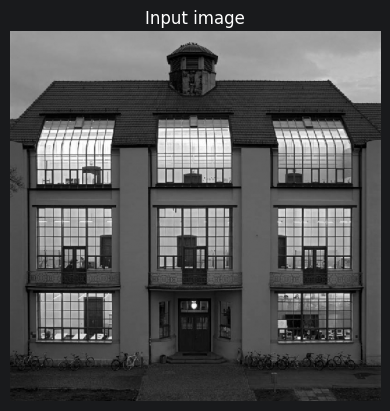

In [49]:
# Load image
I = plt.imread(os.path.join("picturesA4", "taskA.jpg"))

# Convert to grayscale if RGB
if I.ndim == 3:
    I = I.mean(axis=2)

# Convert to double precision and normalize
I = I.astype(np.float64)
I = (I - I.min()) / (I.max() - I.min())

plt.imshow(I, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

### b) Add Gaussian noise to the image (e.g. parameters: mean=0, variance=0.01) and plot the result.

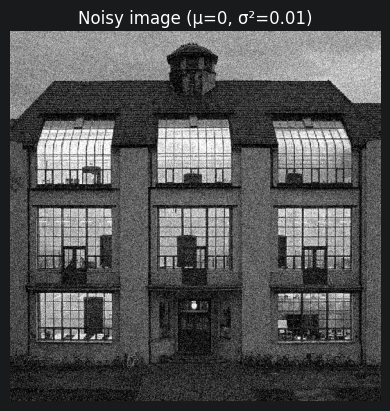

In [50]:
mean = 0
variance = 0.01
sigma = np.sqrt(variance)  # std dev = 0.1

noise = np.random.normal(mean, sigma, I.shape)
I_noisy = I + noise

# Clip to valid range [0, 1] to avoid display artifacts
I_noisy_clipped = np.clip(I_noisy, 0, 1)

plt.imshow(I_noisy_clipped, cmap="gray")
plt.title(f"Noisy image (μ={mean}, σ²={variance})")
plt.axis("off")
plt.show()


### c) Filter the noisy image with a self-computed 2D Gaussian filter in the frequency-domain (<tt>fft2</tt>, <tt>ifft2</tt>). Which 𝜎 is suitable to remove the noise? Plot the result

In [51]:
def gaussian_filter_freq_domain(I_noisy, sigma=10):
    M, N = I_noisy.shape

    # FFT of noisy image
    F_noisy = fft2(I_noisy)
    F_noisy_shifted = fftshift(F_noisy)

    u = np.fft.fftfreq(M) * M
    v = np.fft.fftfreq(N) * M
    u = np.fft.fftshift(u)
    v = np.fft.fftshift(v)
    V, U = np.meshgrid(v,u)

    # gaussian transfer function
    H = np.exp(-(U**2 + V**2) / (2**sigma**2))

    F_filtered_shifted = F_noisy_shifted * H

    # Inverse FFT
    F_filtered = ifftshift(F_noisy_shifted)
    I_filtered = np.real(ifft2(F_filtered))

    spec_noisy    = np.log1p(np.abs(F_noisy_shifted))
    spec_filter   = np.log1p(np.abs(H))              
    spec_filtered = np.log1p(np.abs(F_filtered_shifted))

    return I_filtered, spec_noisy, spec_filter, spec_filtered


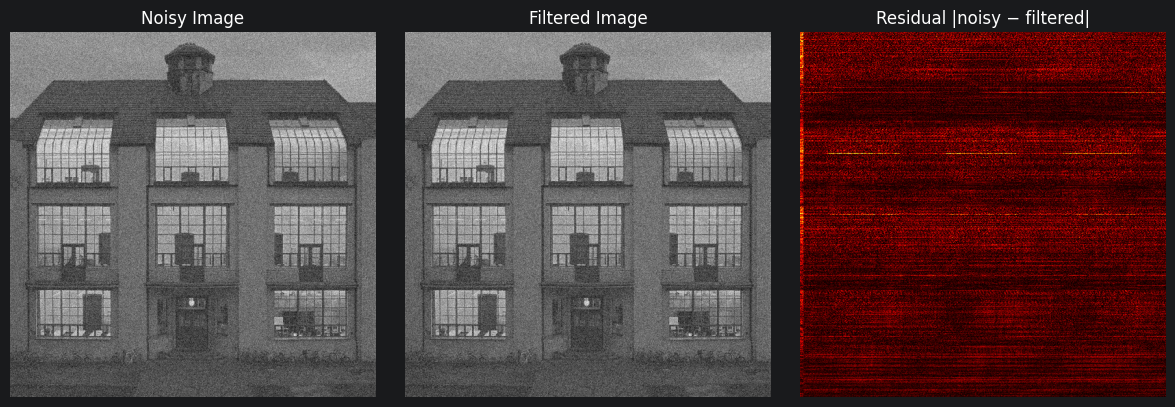

In [52]:
sigma = 3.5
I_filtered, spec_noisy, spec_filter, spec_filtered = gaussian_filter_freq_domain(I_noisy, sigma)

# Plotting spatial domain
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(I_noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(I_filtered, cmap="gray")
plt.title("Filtered Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(np.abs(I_noisy - I_filtered), cmap="hot")
plt.title("Residual |noisy − filtered|")
plt.axis("off")
plt.tight_layout()
plt.show()

### d) Plot the logarithmic centered image spectra of the noisy image, the (padded) Gaussian filter and the filtered image (<tt>log</tt>, <tt>abs</tt> and <tt>fftshift</tt>)

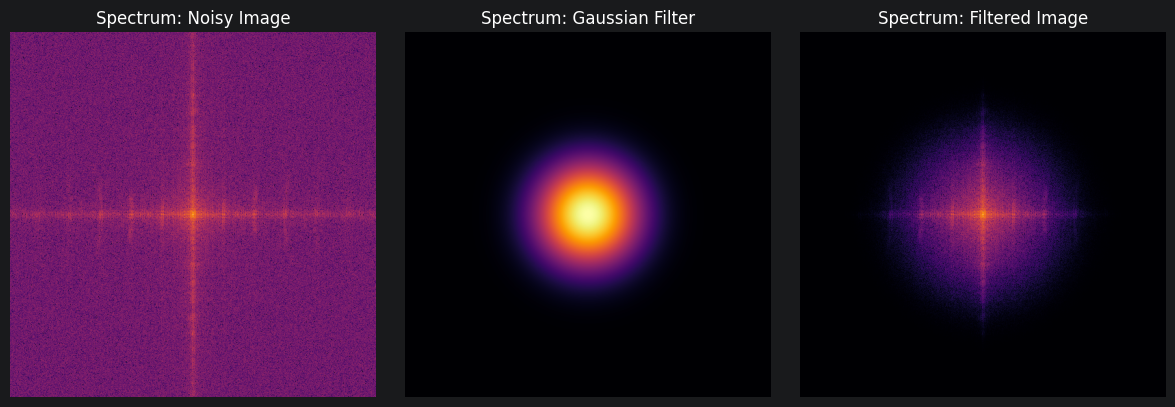

In [53]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(spec_noisy, cmap="inferno")
plt.title("Spectrum: Noisy Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(spec_filter, cmap="inferno")
plt.title("Spectrum: Gaussian Filter")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(spec_filtered, cmap="inferno")
plt.title("Spectrum: Filtered Image")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2) Shape recognition using Fourier descriptors
### a) Read the image <tt>trainB.png</tt> and convert it to a grayscale image (double values between 0.0 and 1.0)

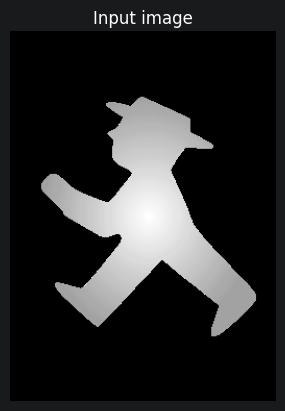

In [54]:
# Load image
I = plt.imread(os.path.join("picturesA4", "trainB.png"))

# Convert to grayscale if RGB
if I.ndim == 3:
    I = I.mean(axis=2)

# Convert to double precision and normalize
I = I.astype(np.float64)
I = (I - I.min()) / (I.max() - I.min())

plt.imshow(I, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

### b) Derive a binary mask of the image where 1 represents the object of interest and 0 represents background (you may use built-in thresholding functions).

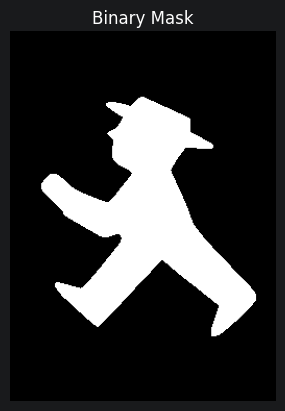

In [55]:
threshold = skimage.filters.threshold_otsu(I)
binary_mask = I > threshold

plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")
plt.show()

### c) Build a Fourier-descriptor $𝐷_𝑓$ based on the binary mask of $b$.

#### c1) Extraction of boundaries of the binary mask (you could use, for example, <tt>measure.find_contours</tt> from the scikit-image library).

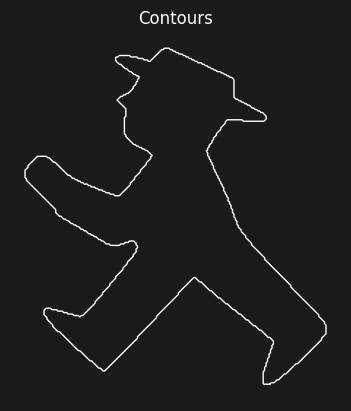

In [56]:
contours = skimage.measure.find_contours(binary_mask, 0.5)

for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], color="white", linewidth=1)

plt.gca().invert_yaxis()
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Contours")
plt.axis("off")

plt.show()

#### c2) Use $𝑛 = 24$ elements for the descriptor.

In [59]:
n = 24
#convert contour to complex coordinates
contour = max(contours, key=len)
complex_coords = contour[:, 1] + 1j * contour[:, 0]
fourier_transform = fft(complex_coords)

if len(fourier_transform) >= n:
    # Take the first n/2 and last n/2 elements (low frequencies)
    half = n // 2
    fourier_transform_truncated = np.concatenate((fourier_transform[:half], fourier_transform[-half:]))
else:
    # pad with zeros if contour is too small
    fourier_transform_truncated = np.zeros(n, dtype=complex)
    fourier_transform_truncated[:len(fourier_transform)] = fourier_transform



#### c3) Make the descriptor invariant to translation, orientation and scale.

### d) Apply steps a.-c. on the images <tt>test1B.jpg</tt>, <tt>test2B.jpg</tt> and <tt>test3B.jpg</tt> in order to identify all potential object boundaries in the images. Note that more than one boundary will be identified in the test images

### e) Identify the object of interest by comparing the trained Fourier-descriptor (result of step c) with all identified descriptors of the test images from step d. Use the Euclidean distance of the Fourier-descriptors for identification, i.e. $norm(𝐷_{𝑓,𝑡rain} − 𝐷_{𝑓,𝑡est}) < 0.09$

### d) Plot the identified boundaries on your mask (result of task b.) in order to validate the results